In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
from esm.models.esmc import ESMC
from esm.sdk.api import ESMProtein, LogitsConfig
from esm.utils.constants.esm3 import (
    SEQUENCE_MASK_TOKEN,
)
import torch
device = torch.device('cuda:0')
model = ESMC.from_pretrained("esmc_600m").to(device) # or "cpu"
vi = {i: a for a, i in model.tokenizer.get_vocab().items()}
AA_str = [vi[i] for i in range(4, 24)]

Fetching 22 files:   0%|          | 0/22 [00:00<?, ?it/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

In [3]:
from go_ml.train_utils import get_elm_df
elm_df = get_elm_df()

In [4]:
import metapredict as meta
def raa(aa):
    if(aa in AA_str):
        return aa
    else:
        return 'A'
sequences = [''.join([raa(aa) for aa in seq]) for seq in elm_df['Sequence']]
# print(sequences[0])
disorder_pred = meta.predict_disorder_batch(sequences)

100%|██████████| 8/8 [00:00<00:00, 11.54it/s]


In [34]:
# import regex as re
# list(re.finditer(elm_df.Regex[0], elm_df.Sequence[0]))
# matches = 0
# for r, regex, seq, s, e in elm_df[['Regex', 'Sequence', 'Start', 'End']].itertuples():
#     matches += not (re.match(regex, seq[s-1:e]) is None)
#     if(re.match(regex, seq[s-1:e]) is None):
#         print(regex, seq[s-1:e])
# print(matches, len(elm_df))
# elm_df.shape, len(elm_df['Primary_Acc'].unique())
#Check that regex match stored elm_df motifs. All but 19 out of 2679 do, with some errors

In [6]:
from collections import OrderedDict
elm_mask = OrderedDict((pid, torch.zeros(800,)) for pid in elm_df['Primary_Acc'])
seq_map = {pid:seq for pid, seq in zip(elm_df['Primary_Acc'], elm_df['Sequence'])}
elm_seq = [seq_map[pid] for pid in elm_mask.keys()]
seq_len = [len(seq) for seq in elm_seq]
for i, pid, si, ei in elm_df[['Primary_Acc', 'Start', 'End']].itertuples():
    elm_mask[pid][si:ei+1] = 1

In [7]:
import pickle
max_len = 800
with open('eval_logits/elm_logits.pkl', 'rb') as f:
   logit_eval_dict = pickle.load(f)

In [8]:
base_ind = list(range(4, 24))
entropy_eval_dict = {k:-(torch.log(prot_msa+1e-6)*prot_msa).sum(dim=-1) for k, prot_msa in logit_eval_dict.items()}
disorder_eval_dict = {k:disorder_pred[i][1] for i, k in enumerate(elm_df['Primary_Acc'])}

In [ ]:
entropy_attr_mat = torch.zeros(len(logit_eval_dict), 800) + torch.log(torch.FloatTensor([20.0]))
elm_mask_mat = torch.zeros(len(logit_eval_dict), 800)
for i, pid in enumerate(elm_mask.keys()):
   ee_seq = entropy_eval_dict[pid]
   entropy_attr_mat[i, 1:ee_seq.shape[0]] =  ee_seq[1:]
   elm_mask_mat[i] = elm_mask[pid]
annot_ind = [torch.nonzero(elm_mask_mat[i]).numpy().flatten().tolist() for i in range(elm_mask_mat.shape[0])]
import pickle
from go_ml.eval_utils import mean_reciprocal_rank, mean_reciprocal_rank_corrected, mean_percent_rank, roc_stats
eeval = -entropy_attr_mat
mrrc = mean_reciprocal_rank_corrected(eeval, annot_ind)
mrr = mean_reciprocal_rank(eeval, annot_ind)
mpr = mean_percent_rank(eeval, torch.LongTensor(seq_len), annot_ind)
roc = roc_stats(eeval, seq_len, annot_ind)
print(f'elm stats', roc, mrrc, mrr, mpr)

elm stats 0.5191639803414875 tensor(0.0733) tensor(0.0206) tensor(0.4666)


In [23]:
# roc = roc_stats(eeval, seq_len, annot_ind)
token_attribution = eeval
conserved_tokens = annot_ind
from sklearn.metrics import roc_curve, auc, average_precision_score

def roc_calc(token_attribution: np.ndarray, seq_len: np.ndarray, conserved_tokens):
    token_labels = np.zeros_like(token_attribution)
    for r in range(len(conserved_tokens)):
        token_labels[r, conserved_tokens[r]] = 1
    fpr_l, tpr_l, auc_l = [], [], []
    for r in range(token_attribution.shape[0]):
        p_labels = token_labels[r, :seq_len[r]]
        p_attribution = token_attribution[r, :seq_len[r]]
        fpr, tpr, thresholds = roc_curve(p_labels, p_attribution)
        roc_auc = auc(fpr, tpr)
        auc_l.append(roc_auc)
    # fpr_l = np.array(fpr_l); tpr_l = np.array(tpr_l); 
    auc_l = np.array(auc_l)
    return auc_l

entr_auc = roc_calc(eeval, seq_len, annot_ind)
dsdr_auc = roc_calc(disorder_attr, seq_len, annot_ind)
c_auc = roc_calc(c_attr, seq_len, annot_ind)

In [25]:
rand_auc = roc_calc(torch.rand(eeval.shape), seq_len, annot_ind)

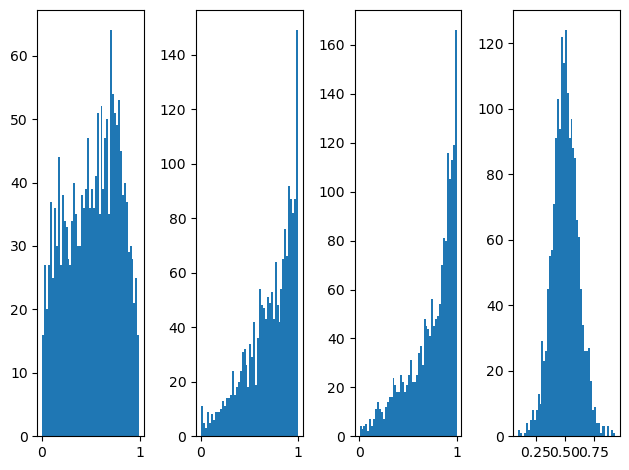

In [27]:
fig, ax = plt.subplots(1, 4)
ax[0].hist(entr_auc, bins=50)
ax[1].hist(dsdr_auc, bins=50)
ax[2].hist(c_auc, bins=50)
ax[3].hist(rand_auc, bins=50)
fig.tight_layout()
plt.show()

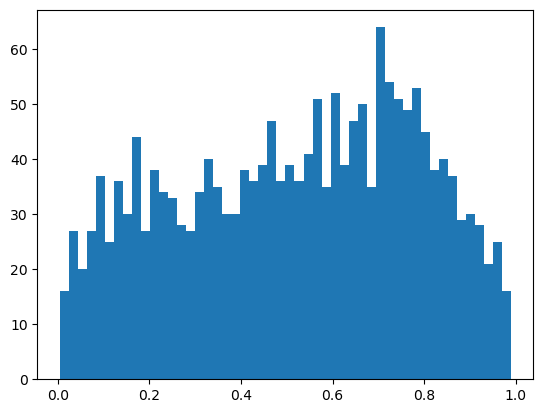

In [ ]:
max_elm_ind = np.argmax(auc_l)
max_elm = list(elm_mask.keys())[max_elm_ind]

In [ ]:
elm_ind = 140
elm_entry = elm_df.iloc[elm_ind]
regex, seq, si, ei = elm_entry[['Regex', 'Sequence', 'Start', 'End']]
# with torch.no_grad():
#     logits = torch.softmax(model(seq_ind).sequence_logits[0], dim=-1).cpu()
logits = logit_eval_dict[elm_entry.Primary_Acc]
# print(regex, seq[si-1:ei])
fig, ax = plt.subplots(1, 1, figsize=(15, 5))
# ax[0].imshow(logits[:, 4:24].cpu().T.float().numpy())
# ax[0].set_yticks(np.arange(0, 20), list(AA_str))
# ax[0].set_xticks(np.arange(0, ei+1-si+10), '_'*5 + seq[si-1:ei] + '_'*5, rotation=90)
ee = (torch.log(logits+1e-6)*logits).sum(dim=-1).float().numpy()
ax.plot(ee[:])
ax.plot(disorder_pred[elm_ind][1])
ax.plot(elm_mask[elm_entry.Primary_Acc])
plt.show()

print(regex, seq[si-1:ei])
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax[0].imshow(logits[si-5:ei+1+5, 4:24].cpu().T.float().numpy())
ax[0].set_yticks(np.arange(0, 20), list(AA_str))
ax[0].set_xticks(np.arange(0, ei+1-si+10), '_'*5 + seq[si-1:ei] + '_'*5, rotation=90)
ee = (torch.log(logits+1e-6)*logits).sum(dim=-1).float().numpy()
ax[1].plot(ee[si-20:ei+1+20])
plt.show()

(tensor(0.), tensor(-2.9957))

In [20]:
def to_attr_mat(attr_dict, elm_mask):
    attr_mat = torch.zeros(len(elm_mask), 800) - 1e0
    for i, pid in enumerate(elm_mask.keys()):
        ee_seq = attr_dict[pid]
        attr_mat[i, 1:ee_seq.shape[0]] =  ee_seq[1:]
    return attr_mat

disorder_attr = to_attr_mat({k: torch.FloatTensor(m) for k, m in disorder_eval_dict.items()}, elm_mask)

mrrc = mean_reciprocal_rank_corrected(disorder_attr, annot_ind)
mrr = mean_reciprocal_rank(disorder_attr, annot_ind)
mpr = mean_percent_rank(disorder_attr, torch.LongTensor(seq_len), annot_ind)
roc = roc_stats(disorder_attr, seq_len, annot_ind)
print(f'elm stats', roc, mrrc, mrr, mpr)

elm stats 0.7085959158598705 tensor(0.1410) tensor(0.0384) tensor(0.3449)


In [33]:
c_attr = disorder_attr * (eeval+5)
mrrc = mean_reciprocal_rank_corrected(c_attr, annot_ind)
mrr = mean_reciprocal_rank(c_attr, annot_ind)
mpr = mean_percent_rank(c_attr, torch.LongTensor(seq_len), annot_ind)
roc = roc_stats(c_attr, seq_len, annot_ind)
print(f'elm stats', roc, mrrc, mrr, mpr)

elm stats 0.772606227035614 tensor(0.2619) tensor(0.0658) tensor(0.2836)


In [166]:
from scipy.signal import convolve
avg_filter = np.ones((12,))
avg_filter /= avg_filter.sum()
def low_pass(seq_score, avg_filter):
    return convolve(seq_score, avg_filter, mode='same')
low_pass_dict = {pid: low_pass(ev.float().numpy(), avg_filter) for pid, ev in entropy_eval_dict.items()}

In [168]:
from scipy.signal import find_peaks
def peak_mask(x):
    m = np.zeros_like(x)
    peaks, peak_info = find_peaks(x, width=10, prominence=0.01)
    # print(peak_info)
    pr = peak_info['prominences']
    left_ips, right_ips = peak_info['left_ips'], peak_info['right_ips']
    for l, r, p in zip(left_ips, right_ips, pr):
        si, ei = np.ceil(l).astype('int'), np.floor(r).astype('int')+1
        # print(si, ei)
        m[si:ei] = p
    # print(peaks)
    # print(peak_info)
    # m[peaks] = 1
    return m
peak_dict = {pid: peak_mask(-ev) for pid, ev in low_pass_dict.items()}

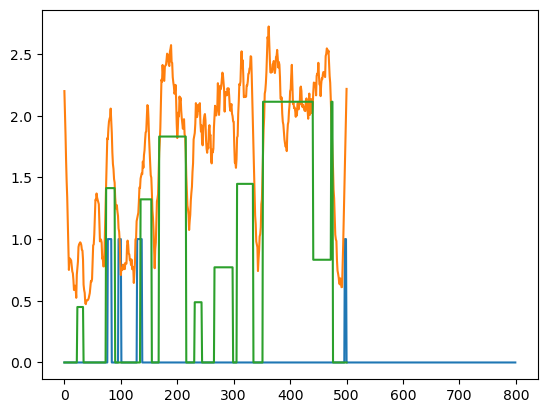

In [216]:
pid = list(elm_mask.keys())[60]
si, ei = 0, elm_mask[pid].shape[0]
plt.plot(elm_mask[pid][si:ei])
# plt.plot(-entropy_eval_dict[pid].float().numpy()[si:ei])
plt.plot(-low_pass_dict[pid][si:ei]+3)
plt.plot(peak_dict[pid][si:ei])
plt.show()

In [4]:
from go_ml.masking import *
def get_logits(seq, batch_size=8, mask_func=mask_indiv):
    seq_ind = model.encode(ESMProtein(sequence=seq)).sequence
    batch, batch_inds, mut_inds = mask_func(seq_ind, SEQUENCE_MASK_TOKEN)
    bert_eval_l = []
    with torch.no_grad():
        for si in range(0, batch.shape[0], batch_size):
            ei = min(batch.shape[0], si+batch_size)
            x = batch[si:ei, :]
            model_eval = model(x)
            bert_eval = model_eval.sequence_logits
            bert_eval_l.append(bert_eval.cpu())
    bert_eval = torch.cat(bert_eval_l)
    bert_eval = torch.softmax(bert_eval, dim=2)
    bert_mask = (batch == SEQUENCE_MASK_TOKEN).cpu()
    eval_avg, eval_support = mask_avg(bert_mask, bert_eval)
    return eval_avg

[DSTE][^P][^DEWHFYC]D[GSAN] TLPDG
['S', 'S', 'E', 'E', 'S']


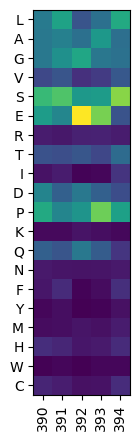

In [215]:
elm_ind = 9
elm_entry = elm_df.iloc[elm_ind]
regex, seq, si, ei = elm_entry[['Regex', 'Sequence', 'Start', 'End']]
print(regex, seq[si-1:ei])
tf_logits = logit_eval_dict[elm_entry.Primary_Acc]
print([AA_str[x] for x in tf_logits[si:ei+1, 4:24].argmax(dim=1).numpy()])

fig, ax = plt.subplots(1, 1, figsize=(15, 5))
plt.imshow(tf_logits[si:ei+1, 4:24].cpu().T.float().numpy())
ax.set_yticks(np.arange(0, 20), list(AA_str))
ax.set_xticks(np.arange(0, ei+1-si), np.arange(si, ei+1), rotation=90)
plt.show()